In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Тема:
Оценка эффективности рекламных каналов (TV, радио, газеты) в формировании продаж продукта.

## Исследовательский вопрос:
Какой из рекламных каналов (TV, радио, газеты) оказывает наибольшее влияние на объем продаж, и можно ли предсказать результат, учитывая нелинейные эффекты взаимодействия между каналами?

In [2]:
ad = pd.read_csv("Advertising.csv")
ad['total'] = ad['TV'] + ad['radio'] + ad['newspaper']
ad

,TV,radio,newspaper,sales,total
0,230.1,37.8,69.2,22.1,337.1
1,44.5,39.3,45.1,10.4,128.9
2,17.2,45.9,69.3,9.3,132.4
3,151.5,41.3,58.5,18.5,251.3
4,180.8,10.8,58.4,12.9,250.0
...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,55.7
196,94.2,4.9,8.1,9.7,107.2
197,177.0,9.3,6.4,12.8,192.7
198,283.6,42.0,66.2,25.5,391.8


In [3]:
X = ad.drop('sales',1)
y = ad['sales']

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=101)

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [6]:
train_errors = []
test_errors = []

for d in range(1,6):
    pol_conv = PolynomialFeatures(degree=d, include_bias=False)
    pol_fs = pol_conv.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(pol_fs, y, test_size=0.3, random_state=101)
    m = LinearRegression()
    m.fit(X_train,y_train)
    m_train_pred = m.predict(X_train)
    m_test_pred = m.predict(X_test)

    
    train_error = np.sqrt(mean_squared_error(y_train,m_train_pred))
    test_error = np.sqrt(mean_squared_error(y_test,m_test_pred))
    train_errors.append(train_error)
    test_errors.append(test_error)

In [7]:
train_errors

[1.734594124329376,
 0.5879358948806718,
 0.4339564616350527,
 0.35171725734455017,
 0.25093562204427505]

In [8]:
test_errors

[1.5161519375993902,
 0.6648835061362487,
 0.5816362729765182,
 0.5074109189923974,
 2.572682668135063]

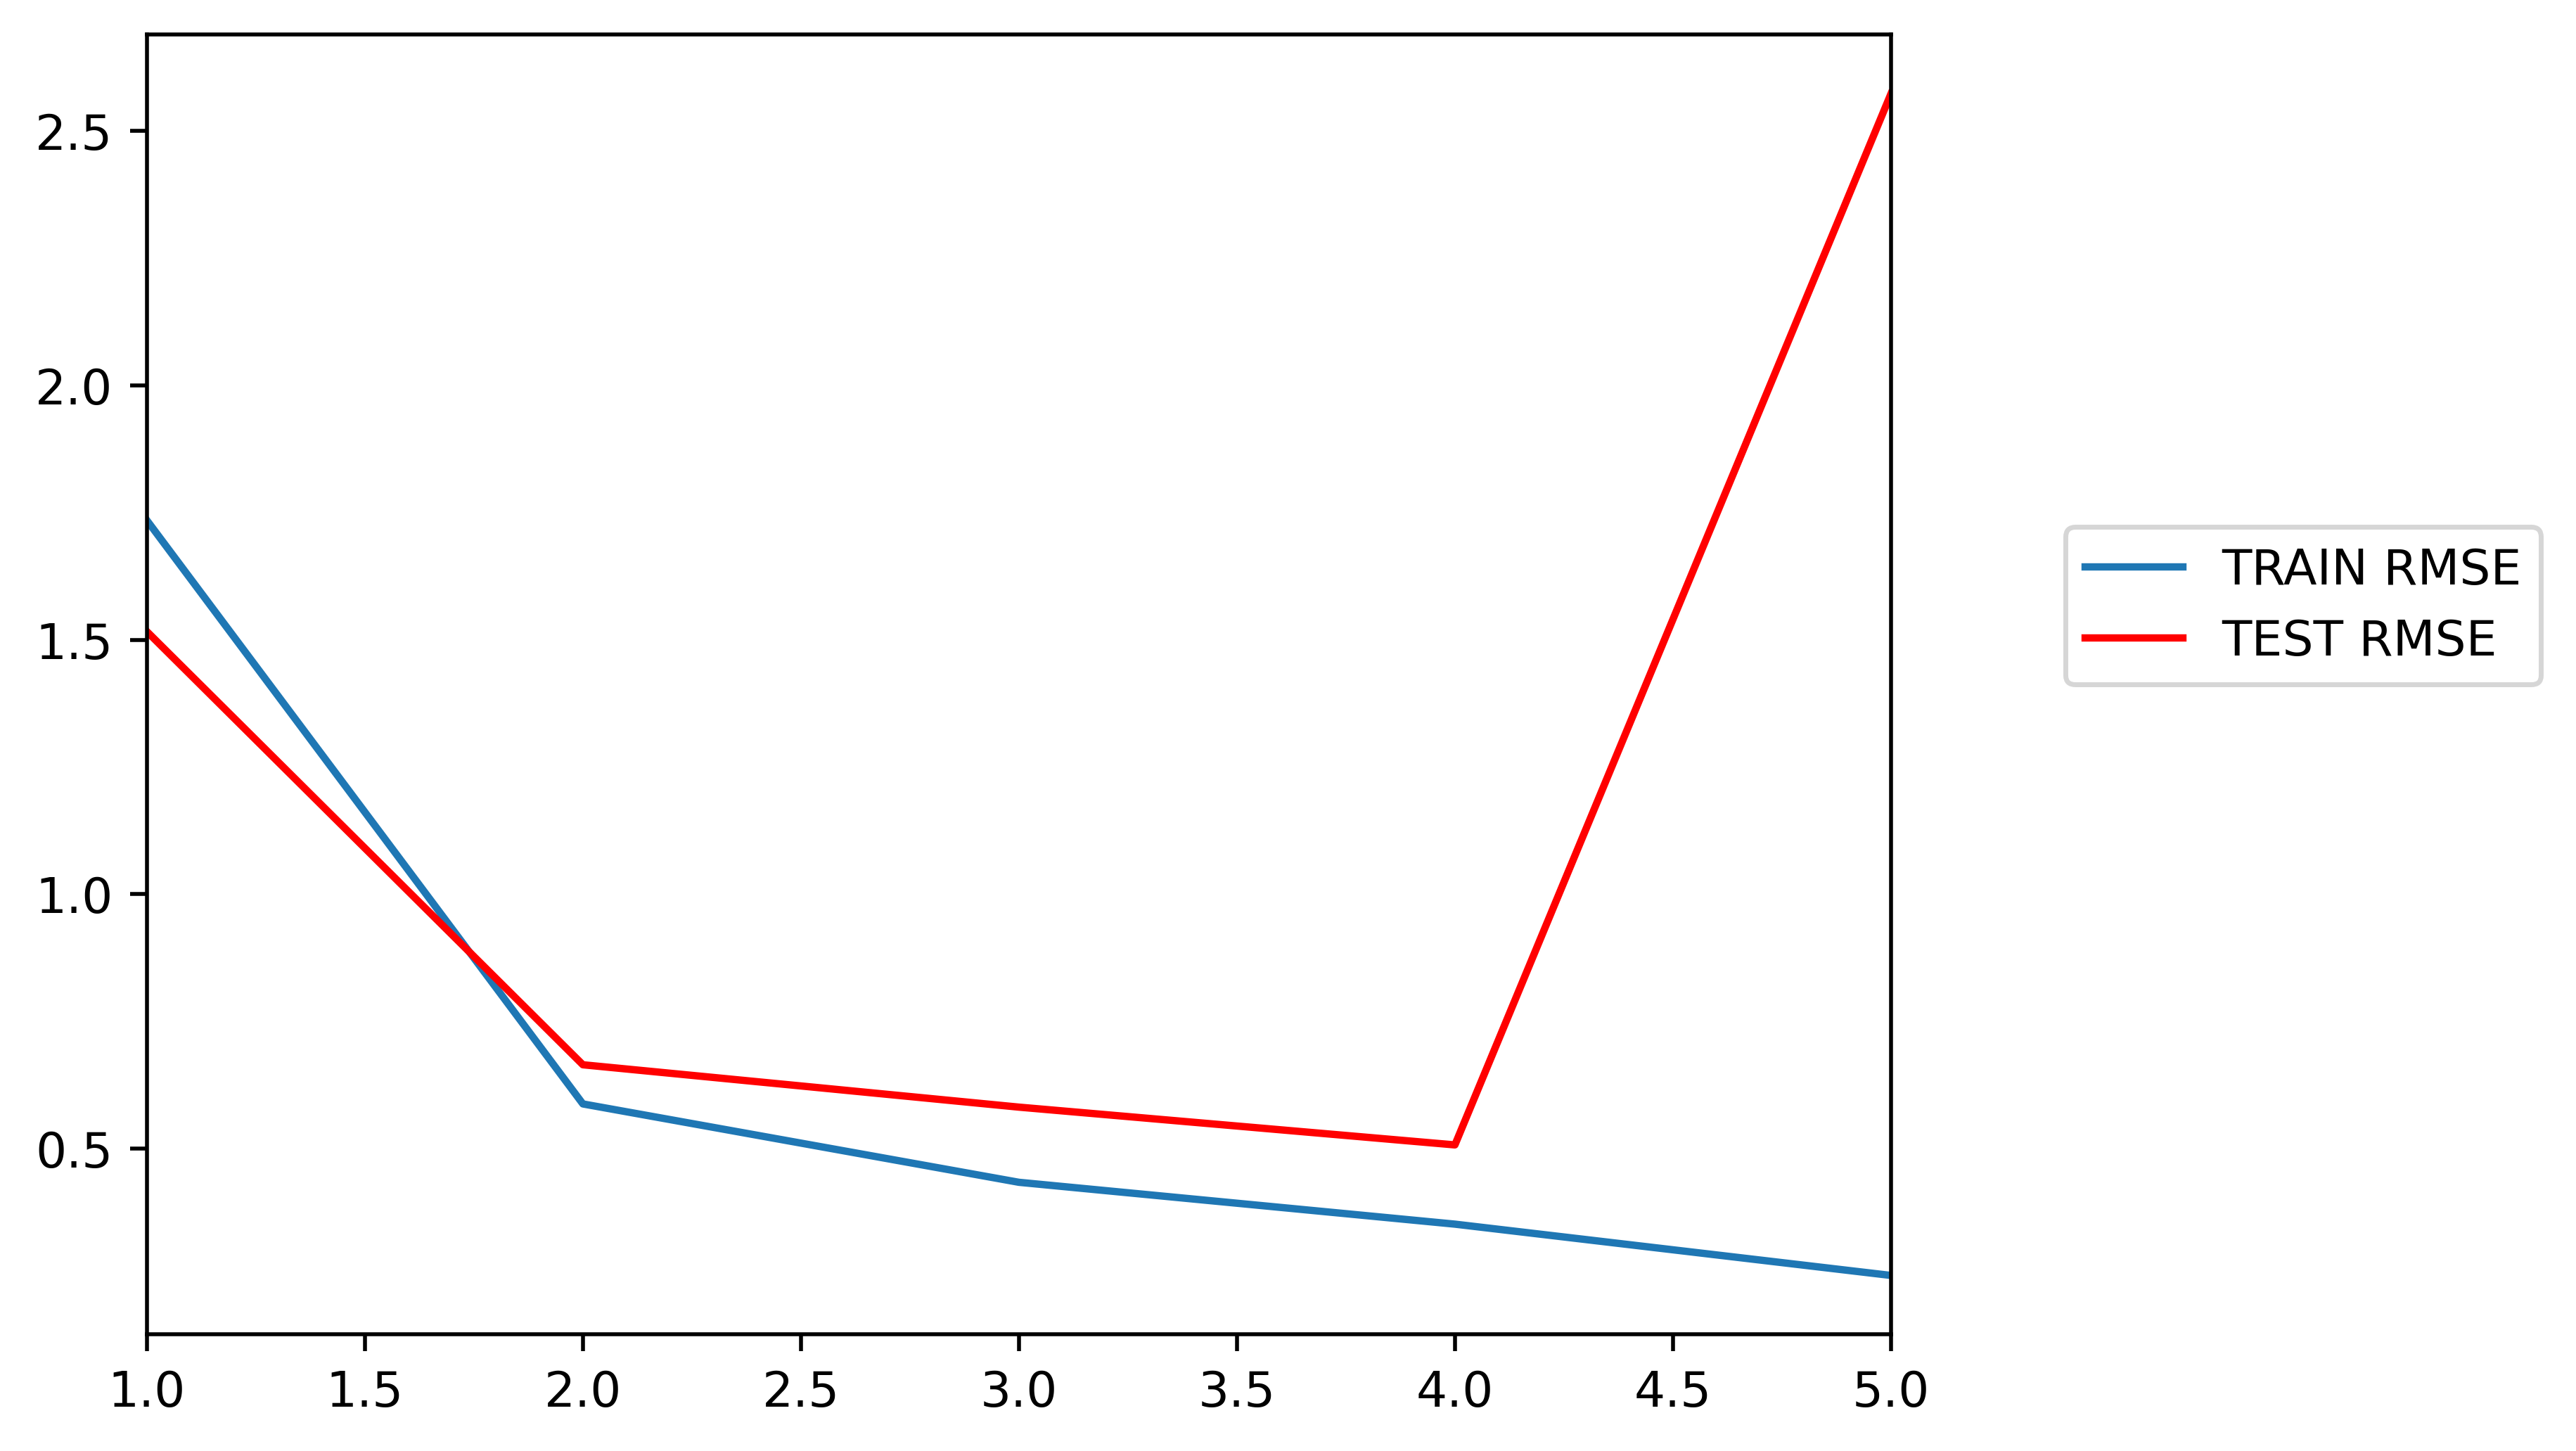

In [9]:
plt.figure(dpi=500)
plt.plot(range(1,6),train_errors,label='TRAIN RMSE')
plt.plot(range(1,6),test_errors,'r',label='TEST RMSE')
plt.xlim([1,5])
plt.legend(loc=[1.1,0.5]);

# Что показала модель с полиномом четвёртой степени:
**TV и радио — основные драйверы продаж.**

Газеты — в исходных данных имеют слабую корреляцию с продажами, их вклад близок к нулю.

Полиномиальная модель улавливает эффекты взаимодействия (например, TV × radio), которые не видит линейная регрессия.

Это объясняет, почему степень 4 дает лучшее качество прогноза.

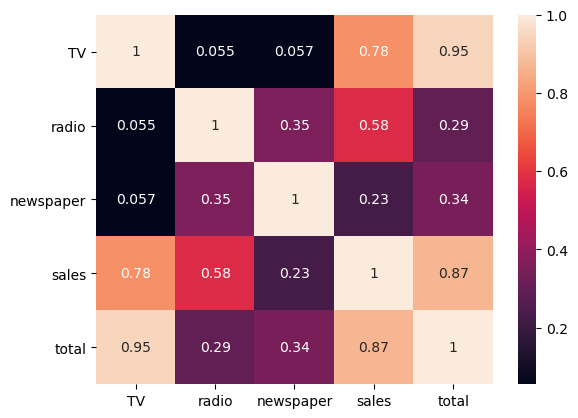

In [10]:
sns.heatmap(ad.corr(),annot=True);

In [11]:
pol_converter = PolynomialFeatures(degree=4,include_bias=False)

In [12]:
pol_features = pol_converter.fit_transform(X)

In [13]:
pol_features.shape

(200, 69)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(pol_features, y, test_size=0.3, random_state=101)

In [15]:
pmodel = LinearRegression()

In [16]:
pmodel.fit(X_train,y_train)

LinearRegression()

In [17]:
ppredictions = pmodel.predict(X_test)

In [18]:
MAE = mean_absolute_error(y_test,ppredictions)
MSE = mean_squared_error(y_test,ppredictions)
RMSE = np.sqrt(MSE)

In [19]:
MAE

0.39244327930225287

In [20]:
MSE

0.2574658407127093

In [21]:
RMSE

0.5074109189923974

In [22]:
np.round(RMSE/ad['sales'].mean(),3)

0.036

**Предсказание:**

In [23]:
np.round(pmodel.predict(pol_converter.transform([[200, 30, 15, 245]]))[0],2)

18.03

# Бизнес-выводы
**Реклама в газетах — неэффективна (в рамках данного набора данных).
Бюджет с газет стоит перераспределить в TV или радио.**

Эффект от TV и радио не аддитивен — их совместное использование дает дополнительный синергетический эффект.

Прогнозная модель (RMSE ~0.51) позволяет маркетологу:

- планировать бюджет с погрешностью ~0.5 тыс. ед. продаж

- оценивать окупаемость рекламных кампаний до их запуска